Optimized Charging Queue (to charging road):
R3 → Charging Road Entry at (2, 4), ETA: 0.07 min, Battery: 15%
R1 → Charging Road Entry at (2, 0), ETA: 0.15 min, Battery: 25%
R2 → Charging Road Entry at (2, 0), ETA: 0.22 min, Battery: 60%


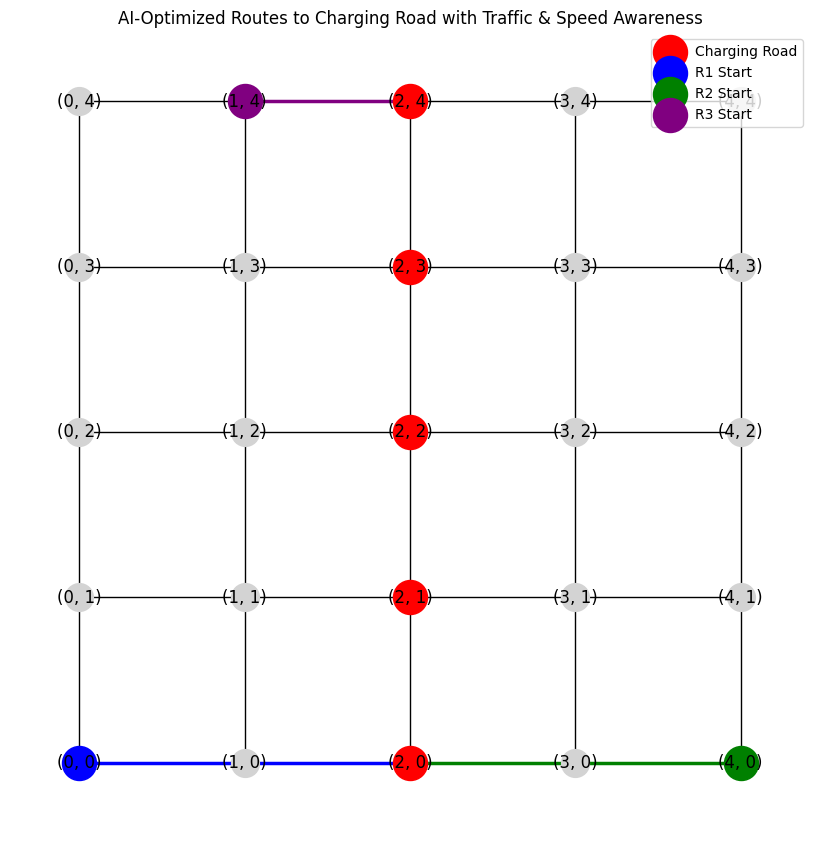

In [2]:
# AI-based Route Optimization and Queue Management for EV Charging (Single Charging Road)

import networkx as nx
import matplotlib.pyplot as plt
import random

# Create a 5x5 grid representing the campus road network
G = nx.grid_2d_graph(5, 5)
pos = dict((n, n) for n in G.nodes())

# Define a single charging road as a set of continuous nodes (e.g., vertical road at x=2)
charging_road = [(2, y) for y in range(5)]

# Define mock e-rickshaws: location, battery percentage, and average speed (m/min)
rickshaws = {
    "R1": {"location": (0, 0), "battery": 25, "speed": 80},
    "R2": {"location": (4, 0), "battery": 60, "speed": 60},
    "R3": {"location": (1, 4), "battery": 15, "speed": 90},
}

# Add edge weights based on simulated traffic (multiplier 0.8 to 1.5)
for u, v in G.edges():
    traffic_factor = random.uniform(0.8, 1.5)
    G[u][v]['weight'] = traffic_factor

# Find nearest point on charging road for each rickshaw
def find_nearest_charging_point(loc, speed):
    min_time = float('inf')
    best_point = None
    best_path = []
    for point in charging_road:
        try:
            path = nx.dijkstra_path(G, loc, point, weight='weight')
            path_length = sum(G[path[i]][path[i + 1]]['weight'] for i in range(len(path) - 1))
            travel_time = (path_length * 5) / speed
            if travel_time < min_time:
                min_time = travel_time
                best_point = point
                best_path = path
        except nx.NetworkXNoPath:
            continue
    return best_point, min_time, best_path

# Build charging queue
queue = []
routes = []
for rid, data in rickshaws.items():
    loc = data["location"]
    battery = data["battery"]
    speed = data["speed"]
    point, eta, path = find_nearest_charging_point(loc, speed)
    queue.append((rid, loc, point, eta, battery))
    routes.append((rid, path))

# Sort queue: priority to lower battery, then shorter ETA
queue.sort(key=lambda x: (x[4], x[3]))

# Display optimized queue
print("Optimized Charging Queue (to charging road):")
for q in queue:
    print(f"{q[0]} → Charging Road Entry at {q[2]}, ETA: {round(q[3], 2)} min, Battery: {q[4]}%")

# Visualization
plt.figure(figsize=(8, 8))
nx.draw(G, pos, with_labels=True, node_size=400, node_color='lightgray')
nx.draw_networkx_nodes(G, pos, nodelist=charging_road, node_color='red', node_size=600, label='Charging Road')

colors = ['blue', 'green', 'purple']
for idx, (rid, path) in enumerate(routes):
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_nodes(G, pos, nodelist=[path[0]], node_color=colors[idx], node_size=600, label=f'{rid} Start')
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=2.5, edge_color=colors[idx])

plt.title("AI-Optimized Routes to Charging Road with Traffic & Speed Awareness")
plt.legend()
plt.axis('off')
plt.show()

Active Charging Queue (Allowed on Charging Road):
R3 → Charging Road Entry at (2, 4), ETA: 0.07 min, Battery: 15%
R4 → Charging Road Entry at (2, 0), ETA: 0.1 min, Battery: 20%

Waiting Queue:
R1 (waiting), ETA: 0.16 min, Battery: 25%
R5 (waiting), ETA: 0.17 min, Battery: 40%
R2 (waiting), ETA: 0.2 min, Battery: 60%


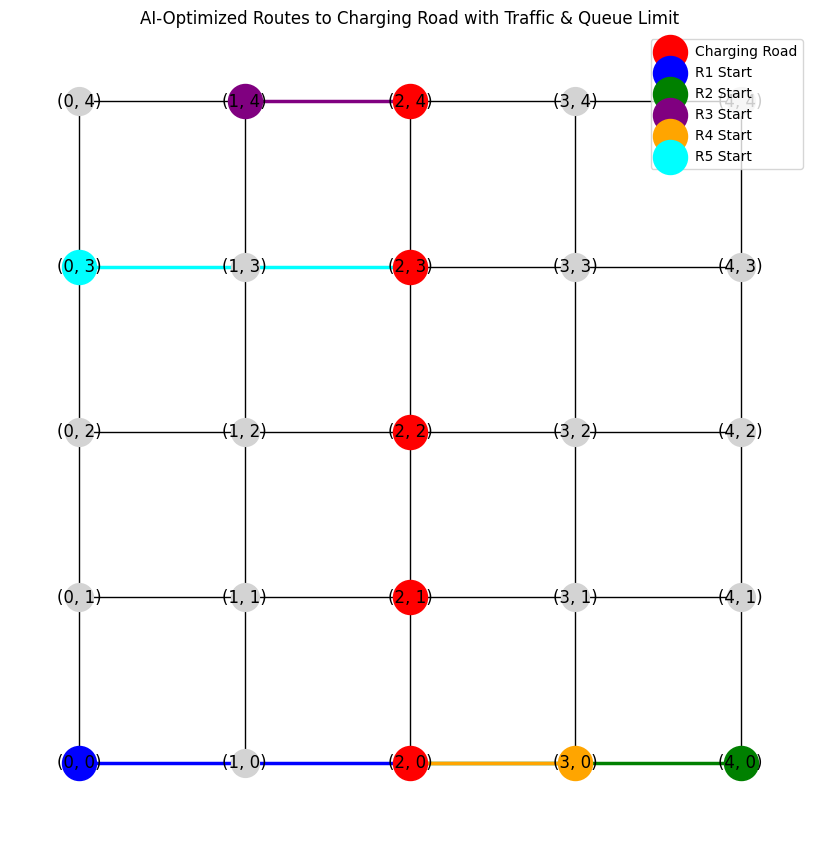

In [3]:
# AI-based Route Optimization and Queue Management for EV Charging (Single Charging Road)

import networkx as nx
import matplotlib.pyplot as plt
import random

# Create a 5x5 grid representing the campus road network
G = nx.grid_2d_graph(5, 5)
pos = dict((n, n) for n in G.nodes())

# Define a single charging road as a set of continuous nodes (e.g., vertical road at x=2)
charging_road = [(2, y) for y in range(5)]

# Max vehicles allowed on charging road at once
MAX_VEHICLES_ON_ROAD = 2

# Define mock e-rickshaws: location, battery percentage, and average speed (m/min)
rickshaws = {
    "R1": {"location": (0, 0), "battery": 25, "speed": 80},
    "R2": {"location": (4, 0), "battery": 60, "speed": 60},
    "R3": {"location": (1, 4), "battery": 15, "speed": 90},
    "R4": {"location": (3, 0), "battery": 20, "speed": 70},
    "R5": {"location": (0, 3), "battery": 40, "speed": 75},
}

# Add edge weights based on simulated traffic (multiplier 0.8 to 1.5)
for u, v in G.edges():
    traffic_factor = random.uniform(0.8, 1.5)
    G[u][v]['weight'] = traffic_factor

# Find nearest point on charging road for each rickshaw
def find_nearest_charging_point(loc, speed):
    min_time = float('inf')
    best_point = None
    best_path = []
    for point in charging_road:
        try:
            path = nx.dijkstra_path(G, loc, point, weight='weight')
            path_length = sum(G[path[i]][path[i + 1]]['weight'] for i in range(len(path) - 1))
            travel_time = (path_length * 5) / speed
            if travel_time < min_time:
                min_time = travel_time
                best_point = point
                best_path = path
        except nx.NetworkXNoPath:
            continue
    return best_point, min_time, best_path

# Build charging queue
queue = []
routes = []
for rid, data in rickshaws.items():
    loc = data["location"]
    battery = data["battery"]
    speed = data["speed"]
    point, eta, path = find_nearest_charging_point(loc, speed)
    queue.append((rid, loc, point, eta, battery))
    routes.append((rid, path))

# Sort queue: priority to lower battery, then shorter ETA
queue.sort(key=lambda x: (x[4], x[3]))

# Limit how many vehicles can be on charging road at once
active_queue = queue[:MAX_VEHICLES_ON_ROAD]
waiting_queue = queue[MAX_VEHICLES_ON_ROAD:]

# Display optimized queue
print("Active Charging Queue (Allowed on Charging Road):")
for q in active_queue:
    print(f"{q[0]} → Charging Road Entry at {q[2]}, ETA: {round(q[3], 2)} min, Battery: {q[4]}%")

print("\nWaiting Queue:")
for q in waiting_queue:
    print(f"{q[0]} (waiting), ETA: {round(q[3], 2)} min, Battery: {q[4]}%")

# Visualization
plt.figure(figsize=(8, 8))
nx.draw(G, pos, with_labels=True, node_size=400, node_color='lightgray')
nx.draw_networkx_nodes(G, pos, nodelist=charging_road, node_color='red', node_size=600, label='Charging Road')

colors = ['blue', 'green', 'purple', 'orange', 'cyan']
for idx, (rid, path) in enumerate(routes):
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_nodes(G, pos, nodelist=[path[0]], node_color=colors[idx], node_size=600, label=f'{rid} Start')
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=2.5, edge_color=colors[idx])

plt.title("AI-Optimized Routes to Charging Road with Traffic & Queue Limit")
plt.legend()
plt.axis('off')
plt.show()



Charging Schedule with Sliding Window:
R3 starts at min 0, charges at (2, 4), exits at min 10
R4 starts at min 0, charges at (2, 0), exits at min 10
R1 starts at min 10, charges at (2, 0), exits at min 20
R5 starts at min 10, charges at (2, 3), exits at min 20
R2 starts at min 20, charges at (2, 0), exits at min 30


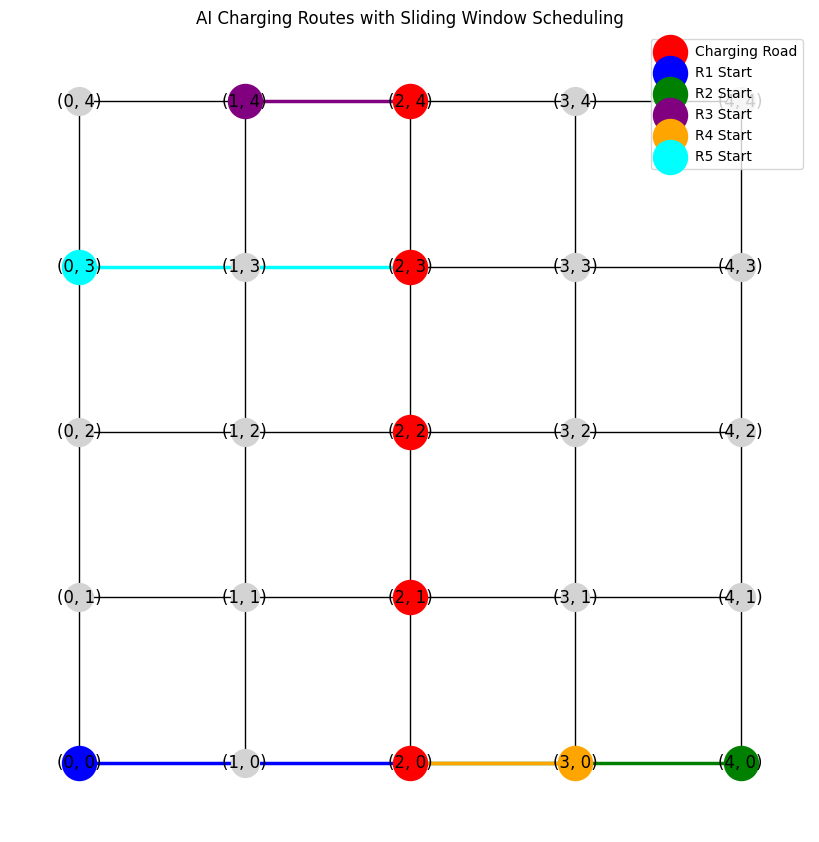

In [4]:
# AI-based Route Optimization and Sliding Window Charging Management

import networkx as nx
import matplotlib.pyplot as plt
import random

# Create a 5x5 grid representing the campus road network
G = nx.grid_2d_graph(5, 5)
pos = dict((n, n) for n in G.nodes())

# Define a single charging road as a set of continuous nodes (e.g., vertical road at x=2)
charging_road = [(2, y) for y in range(5)]

# Max vehicles allowed on charging road at once
MAX_VEHICLES_ON_ROAD = 2
CHARGING_DURATION = 10  # minutes per vehicle

# Define mock e-rickshaws: location, battery percentage, average speed (m/min)
rickshaws = {
    "R1": {"location": (0, 0), "battery": 25, "speed": 80},
    "R2": {"location": (4, 0), "battery": 60, "speed": 60},
    "R3": {"location": (1, 4), "battery": 15, "speed": 90},
    "R4": {"location": (3, 0), "battery": 20, "speed": 70},
    "R5": {"location": (0, 3), "battery": 40, "speed": 75},
}

# Add edge weights with simulated traffic factor
for u, v in G.edges():
    traffic_factor = random.uniform(0.8, 1.5)
    G[u][v]['weight'] = traffic_factor

# Find nearest point on charging road for each rickshaw
def find_nearest_charging_point(loc, speed):
    min_time = float('inf')
    best_point = None
    best_path = []
    for point in charging_road:
        try:
            path = nx.dijkstra_path(G, loc, point, weight='weight')
            path_length = sum(G[path[i]][path[i + 1]]['weight'] for i in range(len(path) - 1))
            travel_time = (path_length * 5) / speed
            if travel_time < min_time:
                min_time = travel_time
                best_point = point
                best_path = path
        except nx.NetworkXNoPath:
            continue
    return best_point, min_time, best_path

# Prepare scheduling queue
events = []
routes = []
for rid, data in rickshaws.items():
    loc = data["location"]
    battery = data["battery"]
    speed = data["speed"]
    point, eta, path = find_nearest_charging_point(loc, speed)
    start_time = round(eta)
    events.append({"id": rid, "start_time": start_time, "battery": battery, "location": loc, "charging_point": point, "path": path})
    routes.append((rid, path))

# Sort by battery then arrival time
events.sort(key=lambda x: (x["battery"], x["start_time"]))

# Simulate 30 minutes with sliding window
timeline = []
active_chargers = []
waiting_queue = events.copy()
charging_log = []

for t in range(31):  # 0 to 30 minutes
    # Remove vehicles done charging
    active_chargers = [c for c in active_chargers if c["end_time"] > t]

    # Check for arriving vehicles
    for r in waiting_queue[:]:
        if r["start_time"] <= t and len(active_chargers) < MAX_VEHICLES_ON_ROAD:
            r["end_time"] = t + CHARGING_DURATION
            active_chargers.append(r)
            charging_log.append((r["id"], r["charging_point"], t, r["end_time"]))
            waiting_queue.remove(r)

# Print the scheduled charging sessions
print("\nCharging Schedule with Sliding Window:")
for entry in charging_log:
    print(f"{entry[0]} starts at min {entry[2]}, charges at {entry[1]}, exits at min {entry[3]}")

# Visualization
plt.figure(figsize=(8, 8))
nx.draw(G, pos, with_labels=True, node_size=400, node_color='lightgray')
nx.draw_networkx_nodes(G, pos, nodelist=charging_road, node_color='red', node_size=600, label='Charging Road')

colors = ['blue', 'green', 'purple', 'orange', 'cyan']
for idx, (rid, path) in enumerate(routes):
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_nodes(G, pos, nodelist=[path[0]], node_color=colors[idx], node_size=600, label=f'{rid} Start')
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=2.5, edge_color=colors[idx])

plt.title("AI Charging Routes with Sliding Window Scheduling")
plt.legend()
plt.axis('off')
plt.show()